# 01 · Fine-tuning the Review Sentiment Model
**ISOM5240 Group Project — Oriental Horizon Hotel Business** · *Student 1*

**Objective:** Classify each guest review as **negative**, **neutral** or **positive**. The share of positive minus negative reviews gives a *Net Reputation Score*. The revenue management system (RMS) uses it to decide whether the hotel's reputation supports a price premium.

**Approach**
1. Load the prepared `sentiment` dataset (from Notebook 00) from the Hugging Face Hub.
2. Fine-tune two pre-trained candidate models from Hugging Face:
   `distilbert-base-uncased` and `distilroberta-base`.
3. Select the better model on the **validation** set (macro-F1, with runtime as tie-breaker).
4. Report the final accuracy on the untouched **test** set.
5. Upload the models to the Hugging Face Hub. The Streamlit app loads the final model,
   `oh-review-sentiment`.

⚠️ **Runtime → Change runtime type → T4 GPU** before running. Training takes about 20–30 minutes.

## 1. Install and import libraries

In [1]:
%pip install -q transformers==5.16.0 accelerate scikit-learn huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.1 MB/s eta 0:00:00


In [2]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub import whoami
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
    set_seed,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "no GPU - training will be very slow")

Device: cuda | Tesla T4


## 2. Configuration

In [3]:
HF_USERNAME = "ludanzhang54"
DATASET_REPO = f"{HF_USERNAME}/oriental-horizon-hotel-reviews"
DATA_DIR = f"hf://datasets/{DATASET_REPO}"   # the CSV files written by Notebook 00

TASK = "sentiment"
LABELS = ['negative', 'neutral', 'positive']
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

# Pre-trained Hugging Face models we compare (both are small, fast "distilled" models).
CANDIDATE_MODELS = ["distilbert-base-uncased", "distilroberta-base"]

# Final model used by the Streamlit app.
FINAL_MODEL_REPO = f"{HF_USERNAME}/oh-review-sentiment"

# Training hyper-parameters
MAX_LENGTH = 256        # reviews longer than 256 tokens are truncated (covers ~95% of reviews)
EPOCHS = 2
LEARNING_RATE = 3e-5
BATCH_SIZE = 32
SEED = 42
set_seed(SEED)

## 3. Load the prepared dataset

In [4]:
train_df = pd.read_csv(f"{DATA_DIR}/{TASK}_train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/{TASK}_val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/{TASK}_test.csv")

for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name:<11} {len(df):>6,} reviews | {df['label'].value_counts().to_dict()}")
train_df.sample(5, random_state=SEED)

train       36,000 reviews | {'positive': 12000, 'negative': 12000, 'neutral': 12000}
validation   4,500 reviews | {'neutral': 1500, 'positive': 1500, 'negative': 1500}
test         4,500 reviews | {'positive': 1500, 'negative': 1500, 'neutral': 1500}


,text,label
16461,The hotel right by marble arch and Hyde park I...,negative
23579,location and clean wasn t great we move four r...,negative
23640,We booked an upgrade room but didn t see any d...,neutral
25635,There is nothing good about this hotel except ...,negative
8840,Very convenient for RAI Very tired rooms Resta...,neutral


## 4. Tokenise the reviews
The model reads numbers, not words. The tokenizer of each pre-trained model splits a review
into sub-word tokens and converts them to IDs. Padding is added per batch later on, which is
faster than padding every review to the maximum length.

In [5]:
class ReviewDataset(torch.utils.data.Dataset):
    """Tokenised reviews plus integer labels, in the format the Trainer expects."""

    def __init__(self, df, tokenizer):
        self.encodings = tokenizer(list(df["text"]), truncation=True, max_length=MAX_LENGTH)
        self.labels = [LABEL2ID[label] for label in df["label"]]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: values[idx] for key, values in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


def compute_metrics(eval_prediction):
    """Accuracy and macro-F1 (F1 averaged over the classes, all weighted equally)."""
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
    }

## 5. Fine-tune each candidate model
Each candidate starts from its pre-trained weights, gets a new output layer (one output per label) and is
trained on our reviews. After every epoch it is scored on the validation set, and the best
epoch is kept.

In [6]:
def short_name(model_name):
    """'distilbert-base-uncased' -> 'distilbert' (used in folder and repository names)."""
    return model_name.split("/")[-1].split("-")[0]


def fine_tune(model_name):
    """Fine-tune one pre-trained model and return its trainer and validation results."""
    set_seed(SEED)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID
    )
    output_dir = f"models/{TASK}-{short_name(model_name)}"
    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        warmup_steps=0.1,                     # first 10% of steps: learning-rate warm-up
        fp16=torch.cuda.is_available(),       # mixed precision = faster on GPU
        logging_steps=50,
        report_to="none",
        seed=SEED,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ReviewDataset(train_df, tokenizer),
        eval_dataset=ReviewDataset(val_df, tokenizer),
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    train_minutes = (time.time() - start) / 60

    val_metrics = trainer.evaluate()
    trainer.save_model(output_dir)            # saves the best epoch + tokenizer
    result = {
        "model": model_name,
        "parameters_millions": round(model.num_parameters() / 1e6, 1),
        "val_accuracy": round(val_metrics["eval_accuracy"], 4),
        "val_macro_f1": round(val_metrics["eval_macro_f1"], 4),
        "train_minutes": round(train_minutes, 1),
        "local_dir": output_dir,
    }
    return trainer, result


trainers, results = {}, []
for model_name in CANDIDATE_MODELS:
    print(f"\n========== Fine-tuning {model_name} ==========")
    trainers[model_name], result = fine_tune(model_name)
    results.append(result)
    print(result)

results_df = pd.DataFrame(results)
results_df


========== Fine-tuning distilbert-base-uncased ==========


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.508570,0.549087,2,0.759778,0.759227


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'model': 'distilroberta-base', 'parameters_millions': 82.1, 'val_accuracy': 0.7598, 'val_macro_f1': 0.7592, 'train_minutes': 6.4, 'local_dir': 'models/sentiment-distilroberta'}


,model,parameters_millions,val_accuracy,val_macro_f1,train_minutes,local_dir
0,distilbert-base-uncased,67.0,0.7544,0.7549,5.9,models/sentiment-distilbert
1,distilroberta-base,82.1,0.7598,0.7592,6.4,models/sentiment-distilroberta


## 6. Select the final model
We pick the candidate with the highest **validation macro-F1**. If two candidates are within
0.5 percentage points, we prefer the smaller (faster) model, because the app runs on a
CPU on Streamlit Cloud.

In [7]:
best_f1 = results_df["val_macro_f1"].max()
close_to_best = results_df[results_df["val_macro_f1"] >= best_f1 - 0.005]
best_row = close_to_best.sort_values("parameters_millions").iloc[0]
BEST_MODEL = best_row["model"]
best_trainer = trainers[BEST_MODEL]
print(f"Selected model: {BEST_MODEL} (validation macro-F1 = {best_row['val_macro_f1']:.4f})")

Selected model: distilbert-base-uncased (validation macro-F1 = 0.7549)


## 7. Final evaluation on the test set
The test set was not used for training or model selection, so this is an unbiased estimate
of how the model performs on new reviews.

Test accuracy : 0.7496
Test macro-F1 : 0.7503

              precision    recall  f1-score   support

    negative     0.8165    0.7860    0.8010      1500
     neutral     0.6345    0.6527    0.6434      1500
    positive     0.8030    0.8100    0.8065      1500

    accuracy                         0.7496      4500
   macro avg     0.7513    0.7496    0.7503      4500
weighted avg     0.7513    0.7496    0.7503      4500



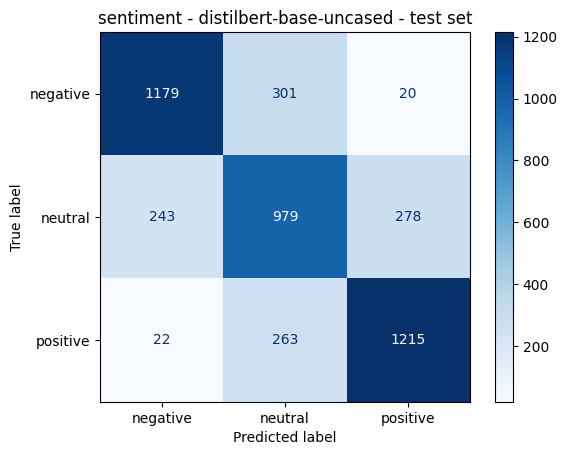

In [8]:
best_tokenizer = best_trainer.processing_class
test_output = best_trainer.predict(ReviewDataset(test_df, best_tokenizer))
test_predictions = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids

print(f"Test accuracy : {accuracy_score(test_labels, test_predictions):.4f}")
print(f"Test macro-F1 : {f1_score(test_labels, test_predictions, average='macro'):.4f}\n")
print(classification_report(test_labels, test_predictions, target_names=LABELS, digits=4, zero_division=0))

ConfusionMatrixDisplay(
    confusion_matrix(test_labels, test_predictions), display_labels=LABELS
).plot(cmap="Blues", values_format="d")
plt.title(f"{TASK} - {BEST_MODEL} - test set")
plt.show()

## 8. Try the model on new reviews (Hugging Face pipeline)

In [9]:
classifier = pipeline(
    "text-classification",
    model=best_trainer.model,
    tokenizer=best_tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)
new_reviews = ['The room was spotless and the staff upgraded us for free. Breakfast was amazing.', 'Location is fine but the room was small and the wifi kept dropping.', 'Dirty bathroom, rude reception and the air conditioning did not work. Never again.']
for review, prediction in zip(new_reviews, classifier(new_reviews)):
    print(f"{prediction['label']:<9} ({prediction['score']:.2f})  {review}")

positive  (0.99)  The room was spotless and the staff upgraded us for free. Breakfast was amazing.
neutral   (0.66)  Location is fine but the room was small and the wifi kept dropping.
negative  (0.99)  Dirty bathroom, rude reception and the air conditioning did not work. Never again.


## 9. Upload the models to the Hugging Face Hub
Both candidates are uploaded (Notebook 03 compares them), and the selected one is uploaded
again under the final name that the Streamlit app uses.
This step needs the Colab secret `HF_TOKEN` (🔑 icon in the left sidebar). Without it the
upload is skipped.

In [10]:
def hf_logged_in_user():
    """Return the logged-in Hugging Face username, or None when no token is available."""
    try:
        return whoami()["name"]
    except Exception:
        return None


if hf_logged_in_user():
    for model_name, trainer in trainers.items():
        repo = f"{HF_USERNAME}/oh-{TASK}-{short_name(model_name)}"
        trainer.model.push_to_hub(repo)
        trainer.processing_class.push_to_hub(repo)
        print("Uploaded candidate:", f"https://huggingface.co/{repo}")
    best_trainer.model.push_to_hub(FINAL_MODEL_REPO)
    best_tokenizer.push_to_hub(FINAL_MODEL_REPO)
    print("Uploaded FINAL model:", f"https://huggingface.co/{FINAL_MODEL_REPO}")
else:
    print("No Hugging Face token found - upload skipped. Models are saved in the 'models' folder.")

os.makedirs("results", exist_ok=True)
results_df.assign(selected=results_df["model"] == BEST_MODEL).to_csv(
    f"results/{TASK}_model_selection.csv", index=False
)

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...bb8gn5p/model.safetensors:   0%|          |  575kB /  268MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...8y1_xne/model.safetensors:   6%|5         | 15.9MB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded FINAL model: https://huggingface.co/ludanzhang54/oh-review-sentiment


## 10. Save the final model files for submission
The final model (weights, configuration and tokenizer) is zipped. Download the zip from the
📁 Files panel on the left; it is the same model the Streamlit app loads.

In [11]:
import shutil

final_dir = f"final_model_{TASK}"
best_trainer.save_model(final_dir)
shutil.make_archive(final_dir, "zip", final_dir)
print(f"Saved {final_dir}.zip:", sorted(os.listdir(final_dir)))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved final_model_sentiment.zip: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']
